# Exploratory Data Analysis
## CVD Fairness Dissertation — NB0b

**Purpose:** Explore feature distributions, sex-stratified patterns, and feature correlations in the cleaned dataset. Findings here informed preprocessing decisions and the clinical benchmarking in later notebooks.

**Input:** `data/processed/cardio_baseline_clean.csv`  
**Outputs:** `outputs/eda/`


## 1. Imports and Paths

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH  = Path("../processed/cardio_baseline_clean.csv")
OUTPUT_DIR = Path("../../outputs/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")

Dataset shape : (68177, 12)
Columns       : ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']


In [ ]:
assert df.isnull().sum().sum() == 0, "Nulls found in EDA dataset"
assert "gender" in df.columns, "gender column missing"
assert "cardio" in df.columns, "cardio column missing"
assert set(df["gender"].unique()) == {0, 1}, "Unexpected gender values"
assert 67000 < len(df) < 69000, f"Unexpected dataset size: {len(df)}"

print(f"Sanity checks passed ({len(df):,} rows)")

Sanity checks passed ✓  (68,177 rows)


## 2. Feature Distributions by Sex

Histograms for all continuous features, split by sex, to check for distributional differences that may affect model behaviour.

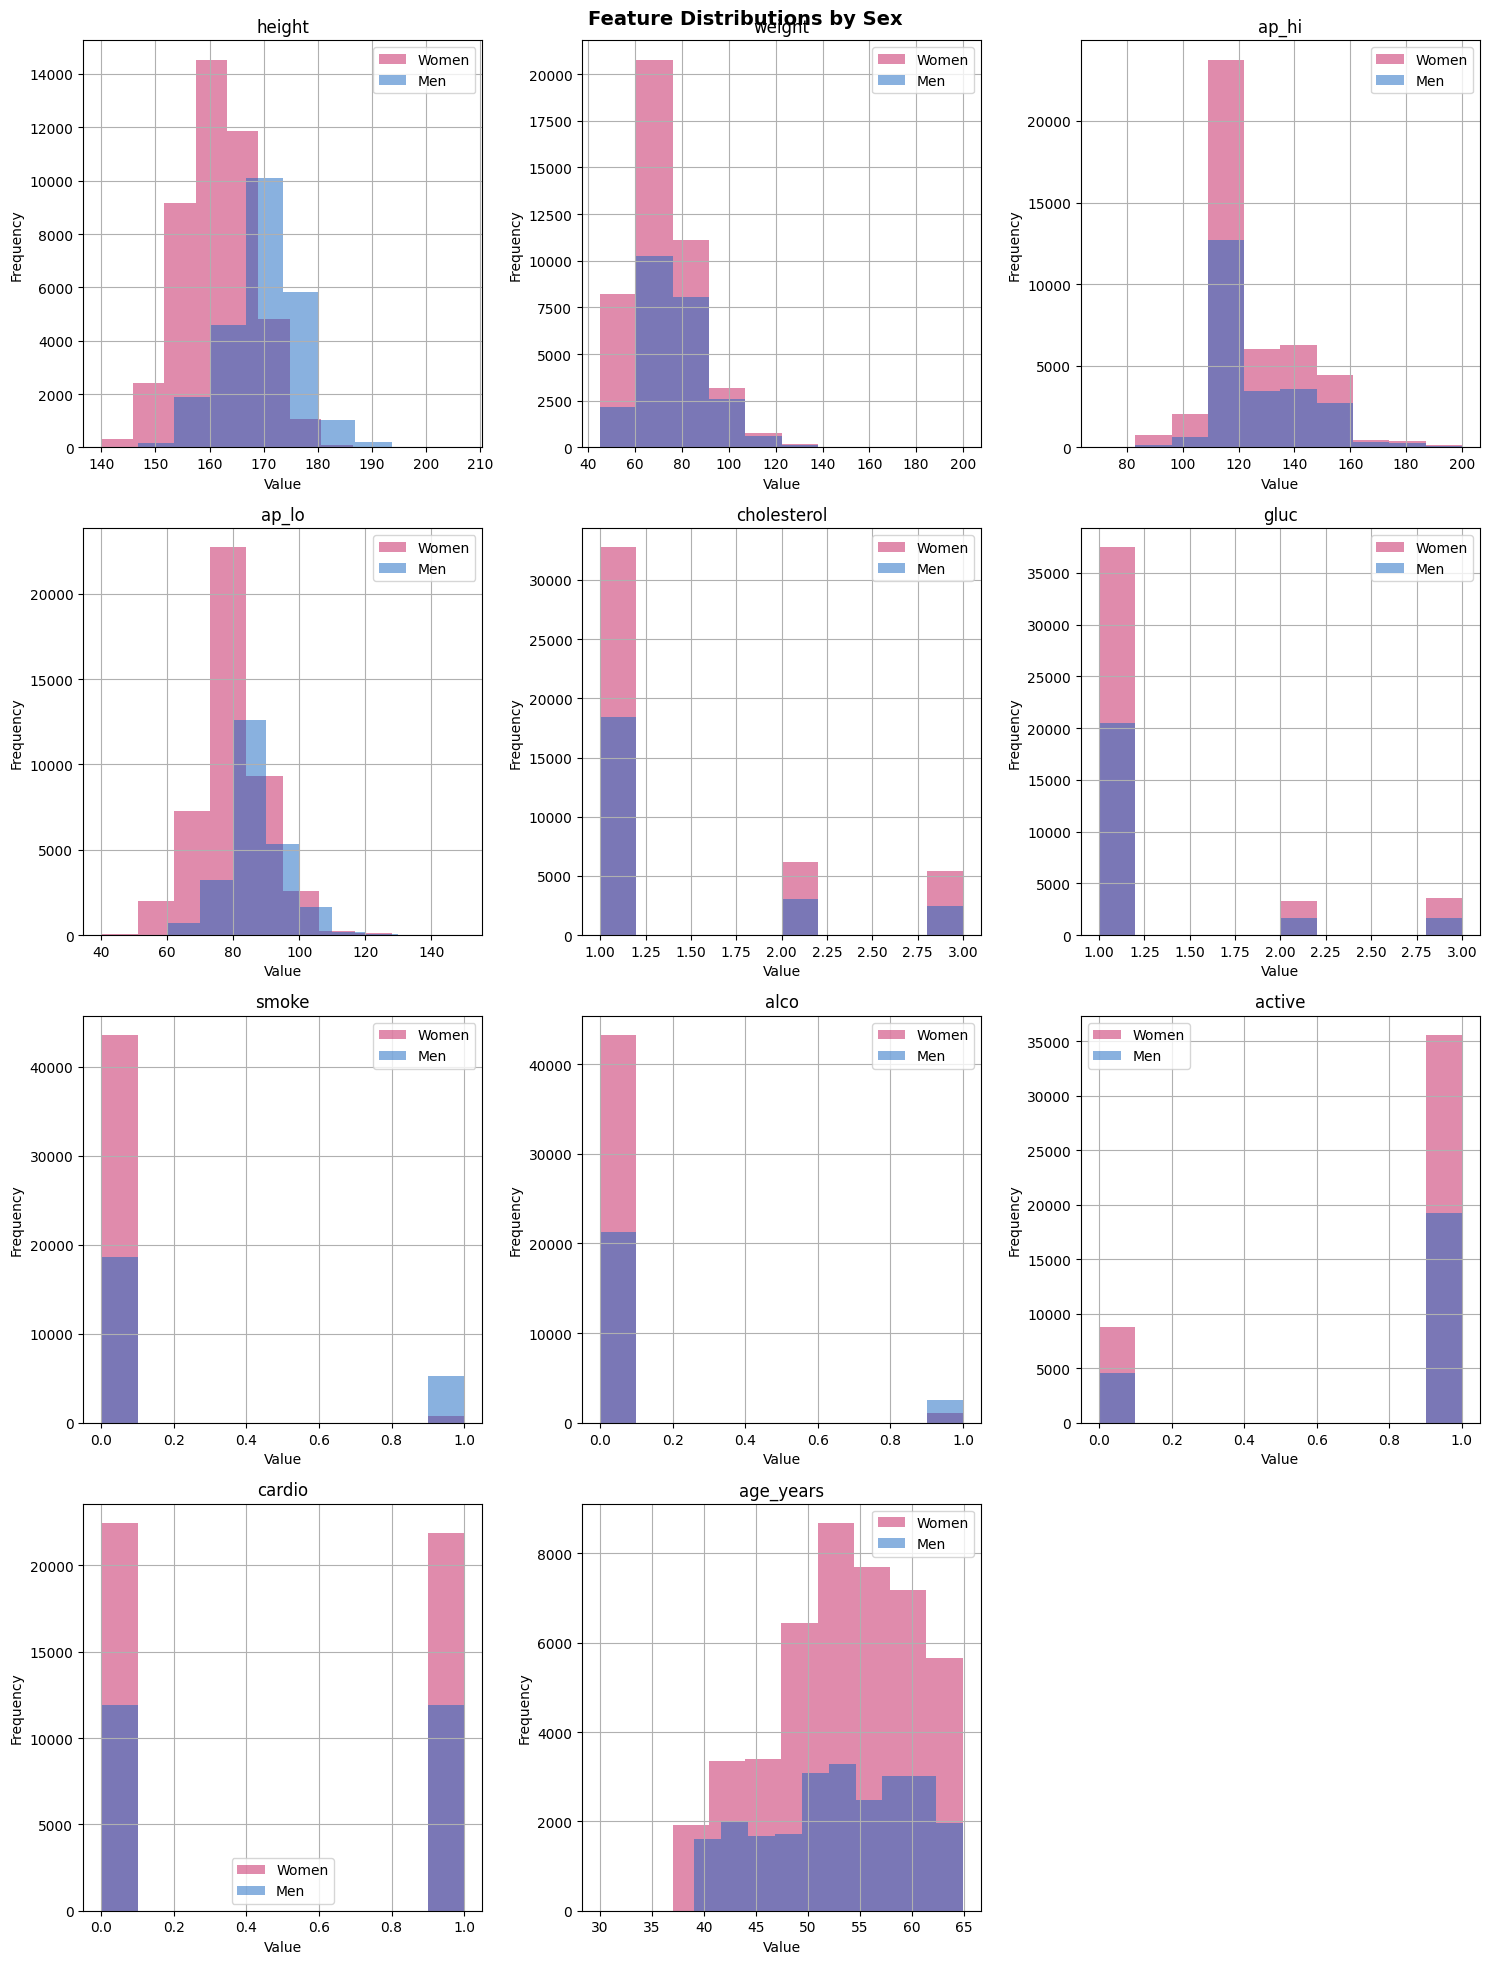

Saved → distributions_by_sex.png


In [7]:
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
numeric_cols = [c for c in numeric_cols if c not in ["gender"]]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[df["gender"] == 0][col].hist(ax=axes[idx], alpha=0.5, label="Women", color="#c2185b")
    df[df["gender"] == 1][col].hist(ax=axes[idx], alpha=0.5, label="Men",   color="#1565c0")
    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distributions by Sex", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distributions_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → distributions_by_sex.png")